In [234]:
# 1_ Load the data from the API Use requests or pd.read_json to fetch data from this endpoint:

import requests
import pandas as pd
import json

In [235]:
limit = 30
skip = 0
dataframes = []

while True:
    url = f"https://dummyjson.com/users?limit={limit}&skip={skip}"

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    data = response.json()
    users = data.get("users", [])

    if not users:
        break

    dataframes.append(pd.json_normalize(users))

    skip += limit
    if len(users) < limit:
        break

df = pd.concat(dataframes, ignore_index=True)
print(df.head())


   id firstName  lastName maidenName  age  gender  \
0   1     Emily   Johnson      Smith   29  female   
1   2   Michael  Williams              36    male   
2   3    Sophia     Brown              43  female   
3   4     James     Davis              46    male   
4   5      Emma    Miller    Johnson   31  female   

                              email             phone  username      password  \
0     emily.johnson@x.dummyjson.com  +81 965-431-3024    emilys    emilyspass   
1  michael.williams@x.dummyjson.com  +49 258-627-6644  michaelw  michaelwpass   
2      sophia.brown@x.dummyjson.com  +81 210-652-2785   sophiab   sophiabpass   
3       james.davis@x.dummyjson.com  +49 614-958-9364    jamesd    jamesdpass   
4       emma.miller@x.dummyjson.com  +91 759-776-1614     emmaj     emmajpass   

   ... company.address.city company.address.state company.address.stateCode  \
0  ...        San Francisco             Wisconsin                        WI   
1  ...          Los Angeles         

In [236]:
# 2_  Basic Data Exploration
  # Shape of the DataFrame

print("Shape of DataFrame:", df.shape)


Shape of DataFrame: (208, 52)


In [237]:
  # List of all column names

print(df.columns.tolist())

['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email', 'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height', 'weight', 'eyeColor', 'ip', 'macAddress', 'university', 'ein', 'ssn', 'userAgent', 'role', 'hair.color', 'hair.type', 'address.address', 'address.city', 'address.state', 'address.stateCode', 'address.postalCode', 'address.coordinates.lat', 'address.coordinates.lng', 'address.country', 'bank.cardExpire', 'bank.cardNumber', 'bank.cardType', 'bank.currency', 'bank.iban', 'company.department', 'company.name', 'company.title', 'company.address.address', 'company.address.city', 'company.address.state', 'company.address.stateCode', 'company.address.postalCode', 'company.address.coordinates.lat', 'company.address.coordinates.lng', 'company.address.country', 'crypto.coin', 'crypto.wallet', 'crypto.network']


In [238]:
  # Data types of each column

print(df.dtypes)

id                                   int64
firstName                           object
lastName                            object
maidenName                          object
age                                  int64
gender                              object
email                               object
phone                               object
username                            object
password                            object
birthDate                           object
image                               object
bloodGroup                          object
height                             float64
weight                             float64
eyeColor                            object
ip                                  object
macAddress                          object
university                          object
ein                                 object
ssn                                 object
userAgent                           object
role                                object
hair.color 

In [239]:
# Number of missing values per column (isnull().sum())

print(df.isnull().sum())


id                                 0
firstName                          0
lastName                           0
maidenName                         0
age                                0
gender                             0
email                              0
phone                              0
username                           0
password                           0
birthDate                          0
image                              0
bloodGroup                         0
height                             0
weight                             0
eyeColor                           0
ip                                 0
macAddress                         0
university                         0
ein                                0
ssn                                0
userAgent                          0
role                               0
hair.color                         0
hair.type                          0
address.address                    0
address.city                       0
a

In [240]:
# Number of duplicate rows (duplicated().sum())

df.duplicated().sum()

np.int64(0)

In [241]:
# Summary statistics for numeric columns (describe())

df.describe()

,id,age,height,weight,address.coordinates.lat,address.coordinates.lng,company.address.coordinates.lat,company.address.coordinates.lng
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,104.500000,33.139423,175.720240,75.038606,-0.357609,-11.729826,2.267603,-2.701298
std,60.188592,5.544269,14.119984,14.090775,53.866250,103.855891,50.015813,99.876659
min,1.000000,23.000000,150.250000,50.100000,-89.077500,-179.958549,-87.103718,-176.705236
25%,52.750000,29.000000,164.187500,62.547500,-52.583475,-101.197683,-40.780079,-83.301244
50%,104.500000,32.000000,177.430000,75.985000,2.925385,-29.607807,7.324804,-6.090248
75%,156.250000,36.000000,186.960000,86.992500,45.281022,71.862635,43.829917,84.288805
max,208.000000,46.000000,199.810000,99.540000,89.781211,179.922909,89.270633,178.804291


In [242]:
df['gender'].value_counts()

,count
gender,
female,106
male,102


In [243]:
df['bloodGroup'].value_counts()

,count
bloodGroup,
O-,31
B-,31
AB-,29
AB+,29
B+,25
O+,22
A+,21
A-,20


In [244]:
df['eyeColor'].value_counts()

,count
eyeColor,
Brown,35
Hazel,34
Green,28
Blue,24
Gray,24
Violet,22
Red,21
Amber,20


In [245]:
df['role'].value_counts()

,count
role,
user,193
moderator,10
admin,5


In [246]:

df['city'] = df['address.city']
df['country'] = df['address.country']
df[['city', 'country']].head()


,city,country
0,Phoenix,United States
1,Houston,United States
2,Washington,United States
3,Seattle,United States
4,Jacksonville,United States


In [247]:
### 3_ Data Cleaning / Preparation (if needed)

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [248]:
  # Handle missing values in age, height, weight (fill with mean/median or drop if few)

numeric_cols_to_clean = ['age', 'height', 'weight']

for col in numeric_cols_to_clean:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

if df[numeric_cols_to_clean].isnull().sum().sum() == 0:
    print("No missing values remain in age, height, weight.")


No missing values remain in age, height, weight.


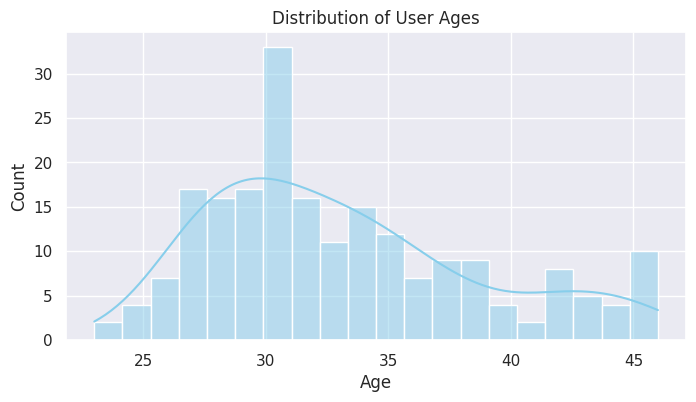

In [249]:
####### Analysis
# average age of users

plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of User Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()



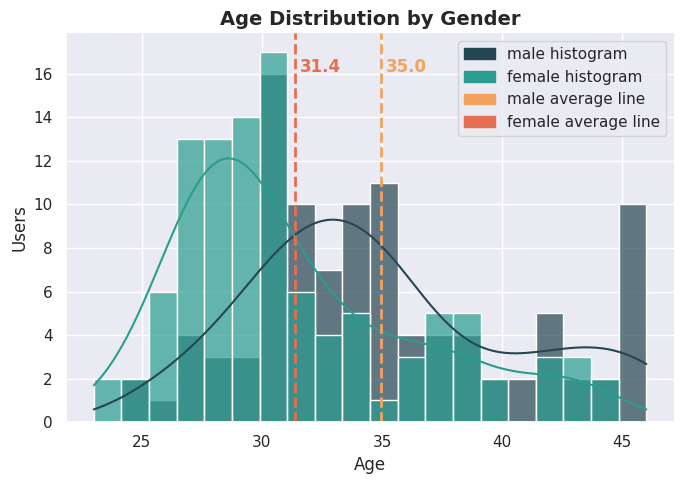

In [250]:


# Age Distribution By Gender

plt.figure(figsize=(7,5))

gender_colors = {'male':'#264653', 'female':'#2a9d8f'}
line_colors = {'male':'#f4a261', 'female':'#e76f51'}

sns.histplot(
    df, x='age', hue='gender', bins=20, kde=True,
    palette=gender_colors, edgecolor='white', alpha=0.7
)

for g in df['gender'].unique():
    avg = df[df['gender']==g]['age'].mean()
    plt.axvline(avg, color=line_colors[g], linestyle='--', linewidth=2)
    plt.text(avg+0.2, plt.gca().get_ylim()[1]*0.9, f'{avg:.1f}', color=line_colors[g], fontweight='bold')

plt.title('Age Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Age'); plt.ylabel('Users')
hist_patches = [mpatches.Patch(color=color, label=f'{g} histogram') for g, color in gender_colors.items()]
line_patches = [mpatches.Patch(color=color, label=f'{g} average line') for g, color in line_colors.items()]
plt.legend(handles=hist_patches + line_patches, loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()


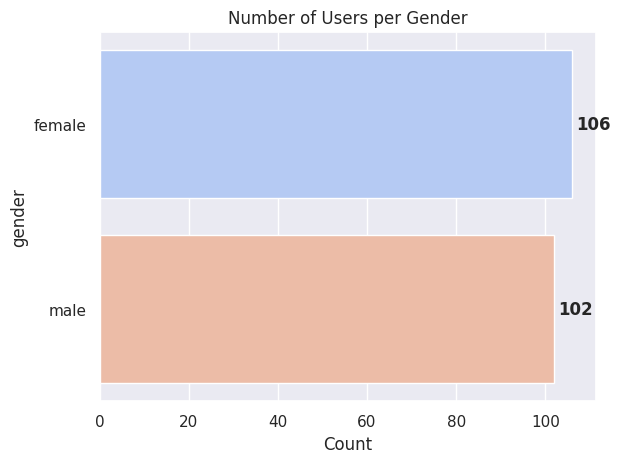

In [251]:
# Number of users per gender

df_count = df['gender'].value_counts().reset_index()
df_count.columns = ['gender','count']

sns.set(style="darkgrid")
bar = sns.barplot(x='count', y='gender', data=df_count, hue='gender', dodge=False, palette="coolwarm", legend=False)
for i, row in df_count.iterrows(): bar.text(row['count']+1, i, row['count'], va='center', fontweight='bold')
plt.title("Number of Users per Gender")
plt.xlabel("Count")
plt.show()


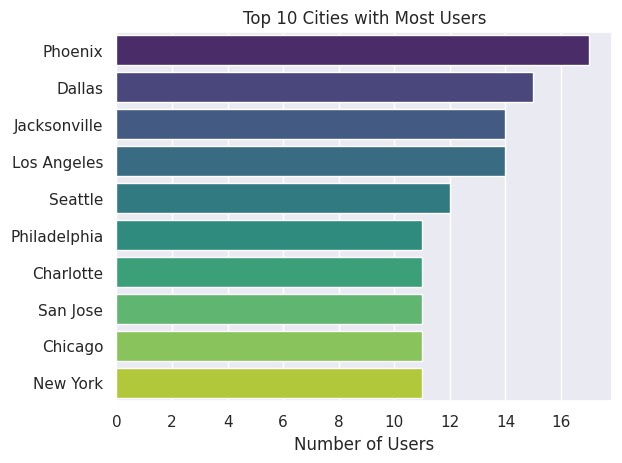

In [252]:
#  Top 10 cities with the most users

df['City'] = df['address.city']
top_cities = df['City'].value_counts().head(10).reset_index()
top_cities.columns = ['city', 'count']
sns.set(style="darkgrid")
sns.barplot(
    x='count', y='city', data=top_cities,
    hue='city', dodge=False, palette="viridis", legend=False
)

plt.title("Top 10 Cities with Most Users")
plt.xlabel("Number of Users")
plt.ylabel("")
plt.show()




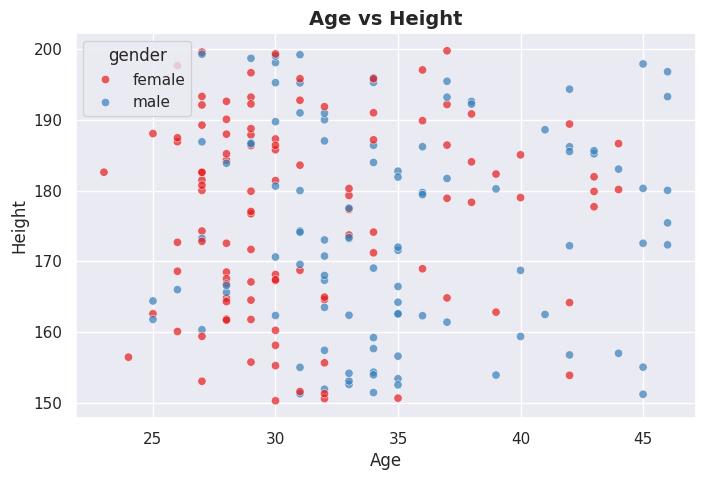

In [253]:
# Age BY Height

sns.set(style="darkgrid")
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='height', data=df, hue='gender', palette="Set1", alpha=0.7)
plt.title("Age vs Height", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Height")
plt.show()



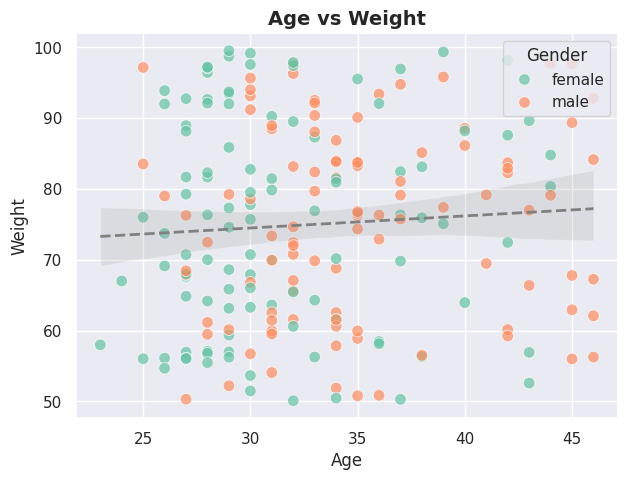

In [254]:
# Age BY Weight

plt.figure(figsize=(7,5))
sns.scatterplot(
    x='age',
    y='weight',
    data=df,
    hue='gender',
    palette="Set2",
    alpha=0.7,
    s=70)

sns.regplot(
    x='age',
    y='weight',
    data=df,
    scatter=False,
    color='gray',
    line_kws={'linestyle':'--', 'linewidth':2})

plt.title("Age vs Weight", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Weight")
plt.legend(title="Gender")
plt.show()
